Mount google drive, will be doing training in google collab using a100

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


download neccessary libraries with specific version, due to recbole being limited using older versions of several other libraries

In [2]:
!pip install -q numpy==1.26.4
!pip install -q pandas==2.2.2 scikit-learn==1.5.1 pyarrow fastparquet
!pip install -q torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121
!pip install -q recbole==1.2.0

In [3]:
!pip install -q ray[tune]==2.31.0

In [4]:
!pip install -q kmeans-pytorch

due to version mismatch correct some values

In [5]:
import numpy as np

if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128

/tmp/ipykernel_13459/2292986966.py:3: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, "bool8"):


check if cuda can be used

In [6]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.3.1+cu121
12.1


In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-40GB


In [8]:
import torch
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error

from recbole.quick_start import run_recbole

This is where all of the train, validation and test data is downloaded and changed to a dataframe

In [9]:
import os
EXPORT_DIR = "/content/drive/MyDrive/"

DATA_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_train.parquet")
print("DATA_PATH:", DATA_PATH)

DATA_PATH: /content/drive/MyDrive/interactions_model_ready_train.parquet


In [10]:
valid_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_valid.parquet")
test_PATH = os.path.join(EXPORT_DIR, "interactions_model_ready_test.parquet")
print("DATA_PATH:", valid_PATH)
print("DATA_PATH:", test_PATH)

DATA_PATH: /content/drive/MyDrive/interactions_model_ready_valid.parquet
DATA_PATH: /content/drive/MyDrive/interactions_model_ready_test.parquet


In [11]:
train_df = pd.read_parquet(DATA_PATH, engine="fastparquet")

In [12]:
valid_df = pd.read_parquet(valid_PATH, engine="fastparquet")
test_df = pd.read_parquet(test_PATH, engine="fastparquet")

In [13]:
valid_df.head()
test_df.head()

,interaction_id,user_idx,item_idx,rating,timestamp,split,original_user_id,original_item_id
0,20086416,817327,259942,5.0,2002-10-01,test,Navigate26266,Hotel_Review-g57049-d259945-Reviews-Logan_Anni...
1,45066978,696486,42865,5.0,2002-10-01,test,LightPacker957,Hotel_Review-g186273-d192533-Reviews-Hilton_Br...
2,37485340,1014807,69119,2.0,2003-03-01,test,Storyteller17290,Hotel_Review-g187791-d191333-Reviews-Albergo_d...
3,40795188,513960,75997,4.0,2003-04-01,test,GrandTour19809,Hotel_Review-g187898-d236030-Reviews-Hotel_Pal...
4,43783134,429208,207670,2.0,2003-04-01,test,Dream37029,Hotel_Review-g34352-d88087-Reviews-Seralago_Ho...


This is where the exported files have a normalized name

In [14]:
def normalize_interaction_schema(df):
    df = df.copy()

    # If exported files use original_user_id / original_item_id, rename them
    if "original_user_id" in df.columns and "user_id" not in df.columns:
        df["user_id"] = df["original_user_id"]

    if "original_item_id" in df.columns and "item_id" not in df.columns:
        df["item_id"] = df["original_item_id"]

    return df

In [17]:
full_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

In [18]:
full_df.head()

,interaction_id,user_idx,item_idx,rating,timestamp,split,original_user_id,original_item_id
0,37347498,711617,206723,1.0,2002-07-01,train,Lorraine7,Hotel_Review-g34172-d88311-Reviews-Best_Wester...
1,13529409,1649570,269376,1.0,2002-08-01,train,mzani,Hotel_Review-g60750-d80133-Reviews-Handlery_Ho...
2,19927246,713942,208141,5.0,2002-08-01,train,Louisville40204,Hotel_Review-g34439-d145476-Reviews-Sherbrooke...
3,28220531,343920,30997,4.0,2002-08-01,train,Cerce,Hotel_Review-g153292-d153995-Reviews-Hotel_Bar...
4,1528489,1607657,116123,4.0,2002-09-01,train,mcguillicudy,Hotel_Review-g264369-d148789-Reviews-Lazy_Parr...


In [20]:
full_df = normalize_interaction_schema(full_df)

This shows the summary of the data, uses full data

In [21]:
required_cols = ["interaction_id", "user_id", "item_id", "rating", "timestamp", "split"]

for name, df in [("full", full_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    print(f"{name} missing columns:", missing)

    print(f"\n{name.upper()} SUMMARY")
    print("rows:", len(df))
    print("unique users:", df["user_id"].nunique())
    print("unique items:", df["item_id"].nunique())
    print("rating min/max:", df["rating"].min(), df["rating"].max())
    print("split values:", df["split"].unique())
    print("timestamp min/max:", df["timestamp"].min(), df["timestamp"].max())
    print("-" * 50)

full missing columns: []

FULL SUMMARY
rows: 19920656
unique users: 1927834
unique items: 309904
rating min/max: 1.0 5.0
split values: ['train' 'valid' 'test']
timestamp min/max: 2002-07-01 00:00:00 2019-09-20 00:00:00
--------------------------------------------------


In [22]:
print(full_df.isnull().sum())

interaction_id      0
user_idx            0
item_idx            0
rating              0
timestamp           0
split               0
original_user_id    0
original_item_id    0
user_id             0
item_id             0
dtype: int64


Makes a copy of the full data, sasrec will split the train, validation and test data in the model. We will get the user_idx, and item_idx and timestamp. We make sure the required  output path exist then save the copy into the output path.

In [23]:
SASRec_df = full_df[['user_idx', 'item_idx', 'timestamp']].copy()
SASRec_df.columns = ['user_id', 'item_id', 'timestamp']

In [24]:
SASRec_df['timestamp'] = pd.to_datetime(SASRec_df['timestamp'])
SASRec_df['timestamp'] = SASRec_df['timestamp'].astype('int64') // 10**9

In [25]:
import os
os.makedirs("/content/drive/MyDrive/256proj/dataset/hotelseq", exist_ok=True)
output_path = "/content/drive/MyDrive/256proj/dataset/hotelseq/hotelseq.inter"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

SASRec_df.to_csv(output_path, sep="\t", index=False)
print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/256proj/dataset/hotelseq/hotelseq.inter


Did the test run with one epoch with less layers and attention heads. USed Cross entropy boss. Later the loss get changed.

In [26]:
SASRec_df.columns = [
    'user_id:token',
    'item_id:token',
    'timestamp:float'
]
SASRec_df.to_csv(output_path, sep='\t', index=False)

In [36]:
resultsbpr = run_recbole(
    model='SASRec',
    dataset='hotelseq',
    config_file_list=["/content/drive/MyDrive/sasrecbprGB.yaml"],
    config_dict={
        "data_path": "/content/drive/MyDrive/256proj/dataset",
        "checkpoint_dir": "/content/drive/MyDrive/256proj/saved"
    }
)

AttributeError: `np.unicode_` was removed in the NumPy 2.0 release. Use `np.str_` instead.

In [34]:
print(resultsbpr)

{'best_valid_score': 0.385, 'valid_score_bigger': True, 'best_valid_result': OrderedDict({'hit@5': 0.4706, 'hit@10': 0.6289, 'hit@20': 0.7788, 'ndcg@5': 0.3338, 'ndcg@10': 0.385, 'ndcg@20': 0.423}), 'test_result': OrderedDict({'hit@5': 0.4636, 'hit@10': 0.6204, 'hit@20': 0.7707, 'ndcg@5': 0.329, 'ndcg@10': 0.3796, 'ndcg@20': 0.4178})}


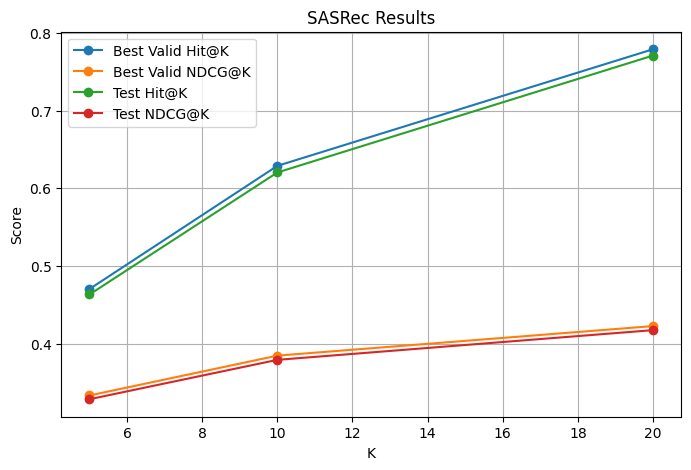

In [40]:
import matplotlib.pyplot as plt

best_valid_result = resultsbpr["best_valid_result"]
test_result = resultsbpr["test_result"]

K = [5, 10, 20]
valid_hit = [best_valid_result[f"hit@{k}"] for k in K]
valid_ndcg = [best_valid_result[f"ndcg@{k}"] for k in K]
test_hit = [test_result[f"hit@{k}"] for k in K]
test_ndcg = [test_result[f"ndcg@{k}"] for k in K]

plt.figure(figsize=(8, 5))
plt.plot(K, valid_hit, marker='o', label="Best Valid Hit@K")
plt.plot(K, valid_ndcg, marker='o', label="Best Valid NDCG@K")
plt.plot(K, test_hit, marker='o', label="Test Hit@K")
plt.plot(K, test_ndcg, marker='o', label="Test NDCG@K")
plt.xlabel("K")
plt.ylabel("Score")
plt.title("SASRec Results")
plt.legend()
plt.grid(True)
plt.show()

There were several changes to the yaml file where the configurations were. I changed the embedding size to 62 with 2 layers and 2 attention heads. The model runs to 10 epochs. I tried to do 20 but runtime disconnected so in order to reduce issues, I chanegd to 10. BPR loss was used instead of cross entropy loss. Instead of all possible hotels, we do bpr which is faster. I changed the batch size of evaluation to make it faster. Validation is using NDCG@10 to determine which is better and the best model is saved. Every epoch is validated and if after 3 epochs and the metrics do not improve, it will stop early. There are evaluation metrics, HR@K for k = 5, 10, 20 and HDGC@K for k = 5, 10 , 20. The training is neg sampling at 1 and the validation and evaluation is geting tested for 100 randomly sampled negative items to save some time.

In [27]:
resultsbprfull = run_recbole(
    model='SASRec',
    dataset='hotelseq',
    config_file_list=["/content/drive/MyDrive/sasrecbprfullGB.yaml"],
    config_dict={
        "data_path": "/content/drive/MyDrive/256proj/dataset",
        "checkpoint_dir": "/content/drive/MyDrive/256proj/saved"
    }
)

/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [28]:
import os

ckpt_dir = "/content/drive/MyDrive/256proj/saved"   # change if needed
pths = [f for f in os.listdir(ckpt_dir) if f.endswith(".pth")]
print(pths)

['SASRec-Apr-24-2026_01-55-55.pth', 'SASRec-Apr-23-2026_20-34-05.pth', 'SASRec-Apr-24-2026_23-13-03.pth']


In [30]:
print(resultsbprfull)

{'best_valid_score': 0.5607, 'valid_score_bigger': True, 'best_valid_result': OrderedDict({'hit@5': 0.6838, 'hit@10': 0.8143, 'hit@20': 0.9067, 'ndcg@5': 0.5183, 'ndcg@10': 0.5607, 'ndcg@20': 0.5843}), 'test_result': OrderedDict({'hit@5': 0.672, 'hit@10': 0.8031, 'hit@20': 0.8983, 'ndcg@5': 0.5089, 'ndcg@10': 0.5515, 'ndcg@20': 0.5758})}


The results are plots for best model and test results for hit@k and NDCG@k for k = 5, 10 ,20.

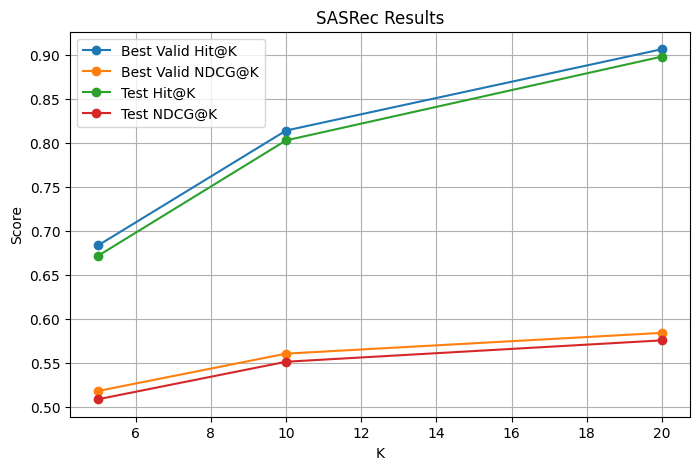

In [29]:
import matplotlib.pyplot as plt

best_valid_result = resultsbprfull["best_valid_result"]
test_result = resultsbprfull["test_result"]

K = [5, 10, 20]
valid_hit = [best_valid_result[f"hit@{k}"] for k in K]
valid_ndcg = [best_valid_result[f"ndcg@{k}"] for k in K]
test_hit = [test_result[f"hit@{k}"] for k in K]
test_ndcg = [test_result[f"ndcg@{k}"] for k in K]

plt.figure(figsize=(8, 5))
plt.plot(K, valid_hit, marker='o', label="Best Valid Hit@K")
plt.plot(K, valid_ndcg, marker='o', label="Best Valid NDCG@K")
plt.plot(K, test_hit, marker='o', label="Test Hit@K")
plt.plot(K, test_ndcg, marker='o', label="Test NDCG@K")
plt.xlabel("K")
plt.ylabel("Score")
plt.title("SASRec Results")
plt.legend()
plt.grid(True)
plt.show()

Saving original results and a cleaner looking one as csv.

In [31]:
pd.DataFrame([resultsbprfull]).to_csv(
    "/content/drive/MyDrive/256proj/resultsbprfull.csv",
    index=False
)

In [32]:
df = pd.DataFrame([resultsbprfull])
df

,best_valid_score,valid_score_bigger,best_valid_result,test_result
0,0.5607,True,"{'hit@5': 0.6838, 'hit@10': 0.8143, 'hit@20': ...","{'hit@5': 0.672, 'hit@10': 0.8031, 'hit@20': 0..."


In [33]:
flat = {
    "best_valid_score": resultsbprfull["best_valid_score"],

    # validation metrics
    **resultsbprfull["best_valid_result"],

    # test metrics (rename with prefix)
    **{f"test_{k}": v for k, v in resultsbprfull["test_result"].items()}
}

import pandas as pd

df_clean = pd.DataFrame([flat])
df_clean

,best_valid_score,hit@5,hit@10,hit@20,ndcg@5,ndcg@10,ndcg@20,test_hit@5,test_hit@10,test_hit@20,test_ndcg@5,test_ndcg@10,test_ndcg@20
0,0.5607,0.6838,0.8143,0.9067,0.5183,0.5607,0.5843,0.672,0.8031,0.8983,0.5089,0.5515,0.5758


In [34]:
df_clean.to_csv(
    "/content/drive/MyDrive/256proj/resultsbprfull_results.csv",
    index=False
)

Used tensorboard logs to get the training loss and valid ngcg@10 score during training over 10 epochs. Then used the logs to plot the results.

In [35]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

log_dir = "/content/log_tensorboard/model-Apr-24-2026_23-13-03"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

print("Available scalar tags:")
print(ea.Tags()["scalars"])

Available scalar tags:
['Loss/Train', 'Vaild_score']


In [57]:
print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['Loss/Train', 'Vaild_score'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [53]:
import pandas as pd
train_loss = [x.value for x in ea.Scalars("Loss/Train")]
valid_score = [x.value for x in ea.Scalars("Vaild_score")]
epochs = list(range(1, len(train_loss) + 1))

df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_loss,
    "valid_ndcg@10": valid_score
})

df

,epoch,train_loss,valid_ndcg@10
0,1,1135.211060,0.4409
1,2,731.378540,0.4765
2,3,643.292847,0.5017
3,4,588.681641,0.5149
4,5,550.513428,0.5301
5,6,521.493042,0.5399
6,7,500.372955,0.5487
7,8,483.659912,0.5519
8,9,470.109283,0.5575
9,10,458.866028,0.5607


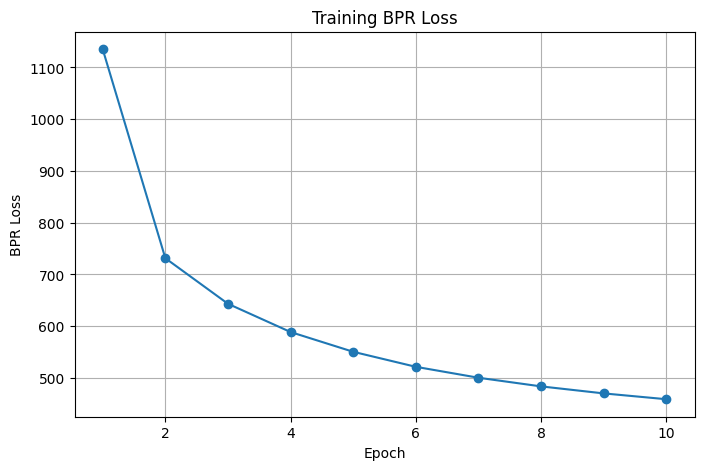

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("Training BPR Loss")
plt.grid(True)
plt.show()

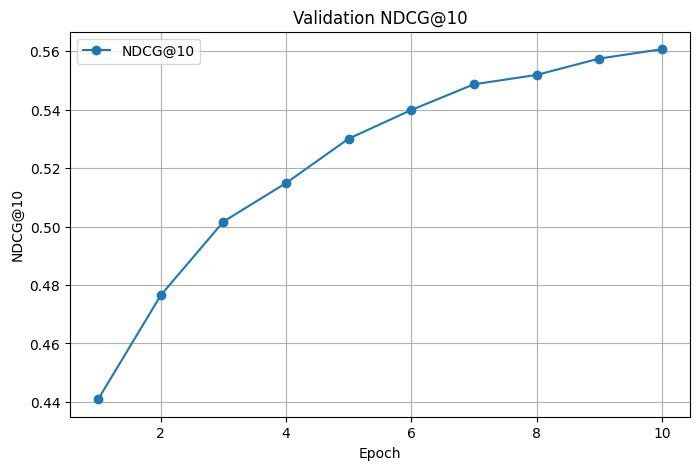

In [56]:
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["valid_ndcg@10"], marker='o', label="NDCG@10")
plt.xlabel("Epoch")
plt.ylabel("NDCG@10")
plt.title("Validation NDCG@10")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
df_new = full_df.copy()

In [59]:
def k_core_filter(df, user_col="user_idx", item_col="item_idx", k=5):
    df = df.copy()

    while True:
        n_before = len(df)

        # filter users
        user_counts = df[user_col].value_counts()
        df = df[df[user_col].isin(user_counts[user_counts >= k].index)]

        # filter items
        item_counts = df[item_col].value_counts()
        df = df[df[item_col].isin(item_counts[item_counts >= k].index)]

        n_after = len(df)

        if n_after == n_before:
            break

    return df.reset_index(drop=True)

In [69]:
df_5core = k_core_filter(df_new, k=10)

In [70]:
df_5core = df_5core.sort_values(
    ["user_idx", "timestamp", "interaction_id"]
).reset_index(drop=True)

In [71]:
print("Original rows:", len(full_df))
print("10-core rows:", len(df_5core))

print("Users:", df_5core["user_idx"].nunique())
print("Items:", df_5core["item_idx"].nunique())

Original rows: 19920656
10-core rows: 10559487
Users: 593100
Items: 177510


In [73]:
resultsbprfullEval = run_recbole(
    model='SASRec',
    dataset='hotelseq',
    config_file_list=["/content/drive/MyDrive/sasrecbprfullEval.yaml"],
    config_dict={
        "data_path": "/content/drive/MyDrive/256proj/dataset",
        "checkpoint_dir": "/content/drive/MyDrive/256proj/saved"
    }
)

/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [74]:
print(resultsbprfullEval)

{'best_valid_score': 0.5607, 'valid_score_bigger': True, 'best_valid_result': OrderedDict({'hit@5': 0.6838, 'hit@10': 0.8143, 'hit@20': 0.9067, 'ndcg@5': 0.5183, 'ndcg@10': 0.5607, 'ndcg@20': 0.5843}), 'test_result': OrderedDict({'hit@5': 0.0048, 'hit@10': 0.0089, 'hit@20': 0.0157, 'ndcg@5': 0.0029, 'ndcg@10': 0.0042, 'ndcg@20': 0.0059})}


In [75]:
pd.DataFrame([resultsbprfullEval]).to_csv(
    "/content/drive/MyDrive/256proj/resultsbprfullEval.csv",
    index=False
)

In [76]:
flat = {
    "best_valid_score": resultsbprfullEval["best_valid_score"],

    # validation metrics
    **resultsbprfullEval["best_valid_result"],

    # test metrics (rename with prefix)
    **{f"test_{k}": v for k, v in resultsbprfullEval["test_result"].items()}
}

import pandas as pd

df_clean = pd.DataFrame([flat])
df_clean.to_csv(
    "/content/drive/MyDrive/256proj/resultsbprfull_resultsEval.csv",
    index=False
)

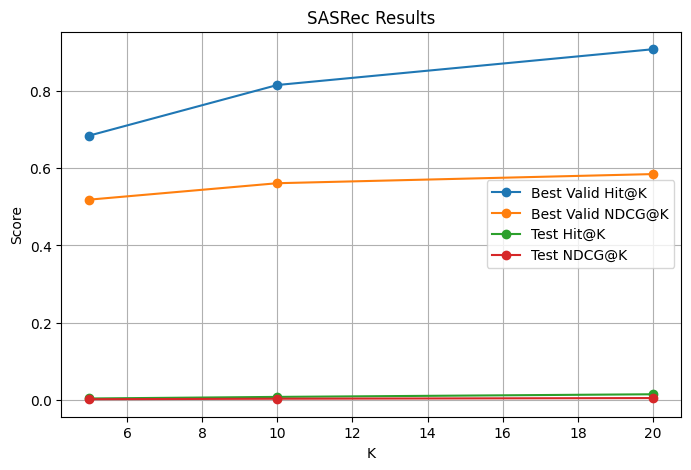

In [77]:
import matplotlib.pyplot as plt

best_valid_result = resultsbprfullEval["best_valid_result"]
test_result = resultsbprfullEval["test_result"]

K = [5, 10, 20]
valid_hit = [best_valid_result[f"hit@{k}"] for k in K]
valid_ndcg = [best_valid_result[f"ndcg@{k}"] for k in K]
test_hit = [test_result[f"hit@{k}"] for k in K]
test_ndcg = [test_result[f"ndcg@{k}"] for k in K]

plt.figure(figsize=(8, 5))
plt.plot(K, valid_hit, marker='o', label="Best Valid Hit@K")
plt.plot(K, valid_ndcg, marker='o', label="Best Valid NDCG@K")
plt.plot(K, test_hit, marker='o', label="Test Hit@K")
plt.plot(K, test_ndcg, marker='o', label="Test NDCG@K")
plt.xlabel("K")
plt.ylabel("Score")
plt.title("SASRec Results")
plt.legend()
plt.grid(True)
plt.show()